<center><h1>Movie Recommender System – Analysis Notebook</h1></center>


This notebook presents the end-to-end workflow and analysis for my Movie Recommender System project. The core idea is to use collaborative filtering (matrix factorization and KNN) on the MovieLens ratings dataset, enrich it with movie metadata from Kaggle, and validate the model predictions against IMDb ratings.

The notebook is organized as follows:

1. Imports
2. Data download and loading
3. Data processing and integration
4. Exploratory Data Analysis (EDA)
5. Model training and prediction
6. Comparing recommendations (SVD vs KNN)
7. External validation with IMDb ratings
8. Conclusions and next steps

## 1. Imports

In this section I import all required Python packages and the project modules that implement the data loading, processing, modeling, analysis, and recommendation logic. The goal is to treat the notebook as a “front-end” on top of the reusable code in the repository.

In [1]:
# Imports
from pathlib import Path
from dotenv import load_dotenv
from surprise import SVD, KNNBaseline
import pandas as pd

load_dotenv(".env")

from config import DATA_DIR, ML_URL, KAGGLE_DATASET_SLUG, IMDB_RATINGS_URL
from config import RESULTS_DIR as outdir
from load import (
    download_movielens_data, download_kaggle_data, download_imdb_ratings,
    load_movielens_ratings, load_movielens_ratings_raw, load_movielens_links,
    load_kaggle_metadata, load_imdb_ratings,
)
from process import filter_transform_metadata, one_hot_encode_genres, merge_datasets
from analyze import generate_plots, imdb_validation
from models import (
    build_surprise_data, surprise_train_test_split,
    tune_SVD, tune_knn_baseline, predict_for_test, predictions_to_dataframe,
)
from recommend import top_n_recommendations, compare_model_recommendations

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## 2. Data Download and Loading

Here I programmatically download and load all datasets used in the project:

- MovieLens (ml-latest-small) – user–movie ratings

- Kaggle Movies Metadata – detailed movie attributes

- IMDb ratings – external benchmark for model validation

The download functions skip retrieval if the required files already exist. To refresh all datasets regardless of their presence, set force_download=True, which triggers a full redownload and replaces existing files.
After downloading, I load MovieLens ratings in both “raw” and pivoted (user × movie) formats, and read the links and metadata files needed for integration.

In [2]:
ml_path = download_movielens_data() # data downloaded and path to directory returned
kg_path = download_kaggle_data() # data downloaded and path to directory returned
imdb_path = download_imdb_ratings() # data downloaded and path to file returned

MovieLens data already present. Skipping download.
Required Kaggle files already present. Skipping download.
The IMDB TSV already exists. Skipping download.


In [3]:
# Loading movielens data
ml_ratings = load_movielens_ratings(ml_path/"ratings.csv")
ml_ratings_raw = load_movielens_ratings_raw(ml_path/"ratings.csv")
ml_links = load_movielens_links(ml_path/"links.csv")
ml_ratings_raw.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
# Loading imdb ratings
imdb_ratings = load_imdb_ratings(imdb_path)
imdb_ratings.head()

,tconst,averageRating,numVotes
0,tt0000001,5.7,2184
1,tt0000002,5.5,305
2,tt0000003,6.4,2267
3,tt0000004,5.2,196
4,tt0000005,6.2,3008


In [5]:
# Loading movies metadata
kg_movies_metadata = load_kaggle_metadata(kg_path/"movies_metadata.csv")
kg_movies_metadata.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


## 3. Data Processing and Integration

In this section I clean and transform the raw metadata, extract useful fields, encode genres, and merge MovieLens movies with their corresponding metadata and IMDb records.

Key steps:

- Filter Kaggle metadata to only movies that appear in MovieLens

- Parse and standardize genre information

- Derive release year and clean numeric fields (runtime, budget, revenue)

- One-hot encode genres for later EDA

- Merge in IMDb ratings and vote counts for use as an external benchmark

In [6]:
# Processing movies metadata
movie_ids = ml_links["tmdbId"].dropna().astype("Int64").unique()
meta_clean = filter_transform_metadata(kg_movies_metadata, movie_ids)
meta_with_genres = one_hot_encode_genres(meta_clean) # One-hot encode genres
meta_merged = merge_datasets(ml_links, meta_with_genres, imdb_ratings)
meta_merged.head()

,movieId,tmdbId,imdbId,title,original_language,release_date,runtime,budget,revenue,year,...,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,imdb_averageRating,imdb_numVotes
0,1,862,tt0114709,Toy Story,en,1995-10-30,81.0,30000000.0,373554033.0,1995,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.3,1148074.0
1,2,8844,tt0113497,Jumanji,en,1995-12-15,104.0,65000000.0,262797249.0,1995,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.1,404748.0
2,3,15602,tt0113228,Grumpier Old Men,en,1995-12-22,101.0,0.0,0.0,1995,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,6.7,31186.0
3,4,31357,tt0114885,Waiting to Exhale,en,1995-12-22,127.0,16000000.0,81452156.0,1995,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,6.0,13151.0
4,5,11862,tt0113041,Father of the Bride Part II,en,1995-02-10,106.0,0.0,76578911.0,1995,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.1,44316.0


At this point, meta_merged contains one row per movie with:

- MovieLens IDs (movieId / tmdbId / imdbId)

- Title, original language, release date, runtime, budget, revenue, release year

- One-hot genre columns

- imdb_averageRating and imdb_numVotes

## 4. EDA

I now explore the main characteristics of the dataset to understand user behavior and the movie catalog.

The plots below summarize:

- How many movies each user rates

- How movies are distributed over release years

- The main languages represented in the catalog

- The most frequent genres

In [7]:
# EDA - generating plots
generate_plots(meta_merged, ml_ratings)

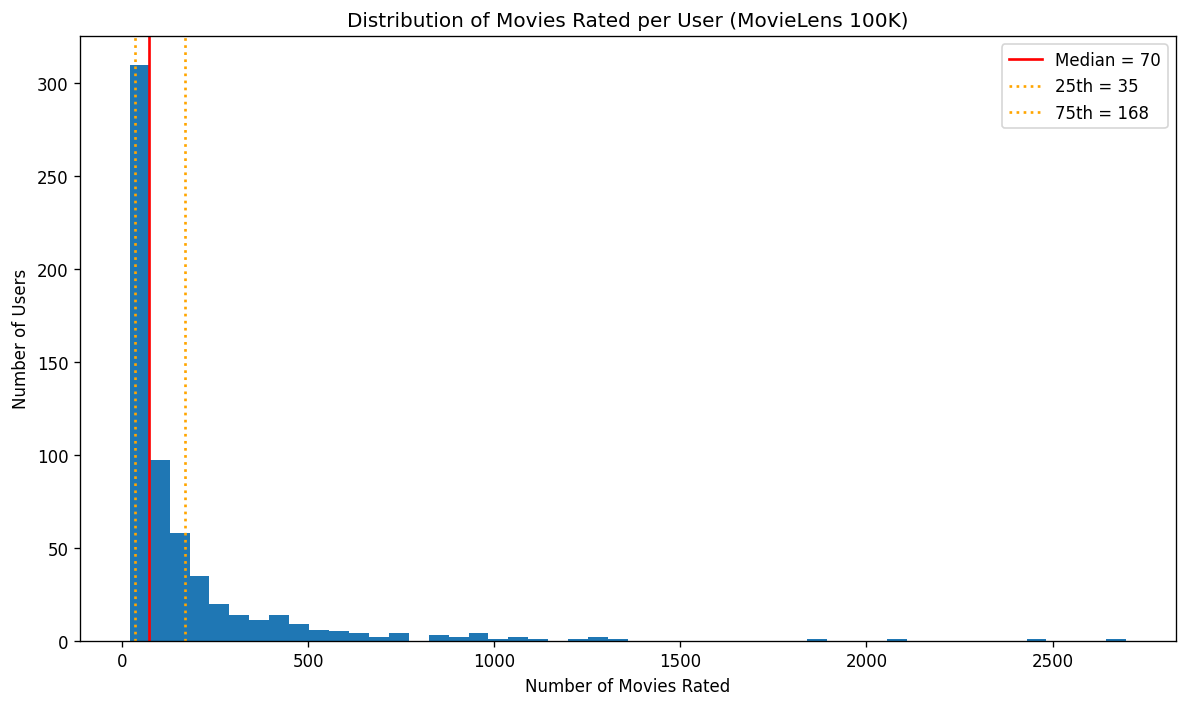


**Interpretation: Distribution of Movies Rated per User**

The number of movies rated per user is highly skewed. Most users have rated relatively few movies, with the 25th percentile at about 35 ratings, the median around 70, and the 75th percentile near 170. A small group of very active users has rated several hundred (or even over a thousand) movies, forming a long right tail. This confirms that the rating matrix is sparse and dominated by light users, which is a typical setting for collaborative filtering.

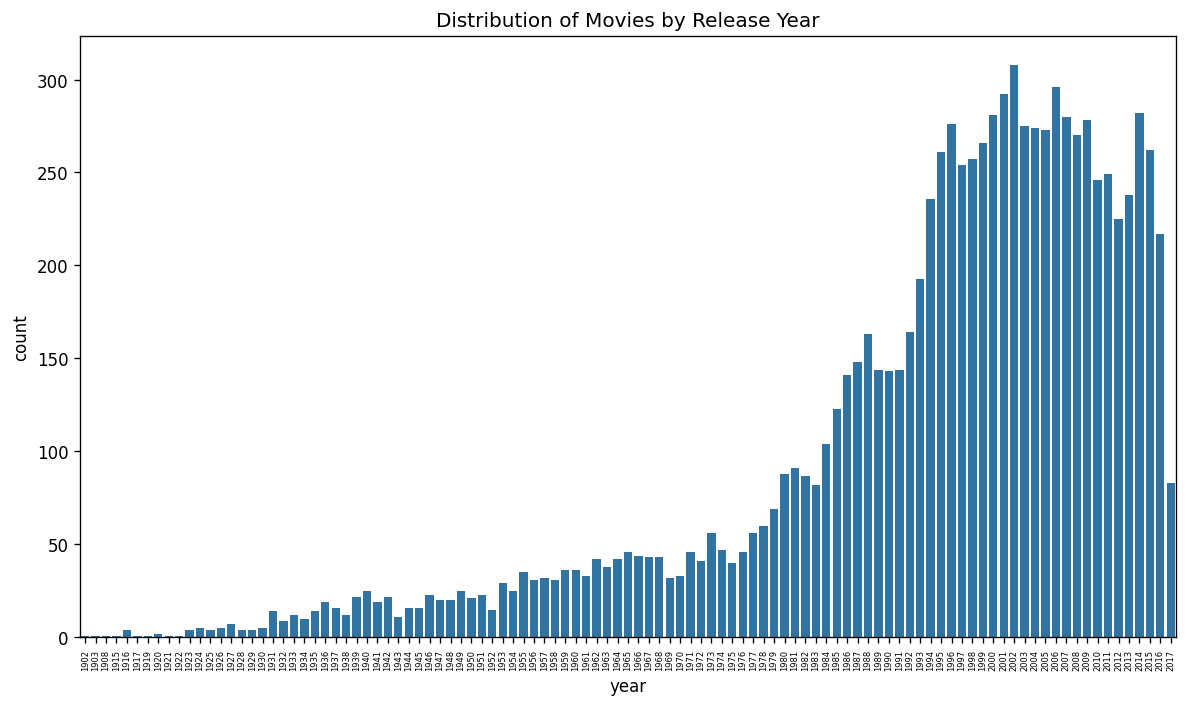


**Interpretation: Distribution of Movies by Release Year**

The release-year distribution shows a steady growth in the number of movies over time, with very few titles in the early decades and a sharp increase from the 1980s onward. The peak density is in the 1990s and 2000s, where each year contributes well over a hundred movies. Recent years (post-2010) remain heavily represented, which means the catalog is skewed toward modern films, an important consideration when interpreting recommendations and IMDb comparisons.

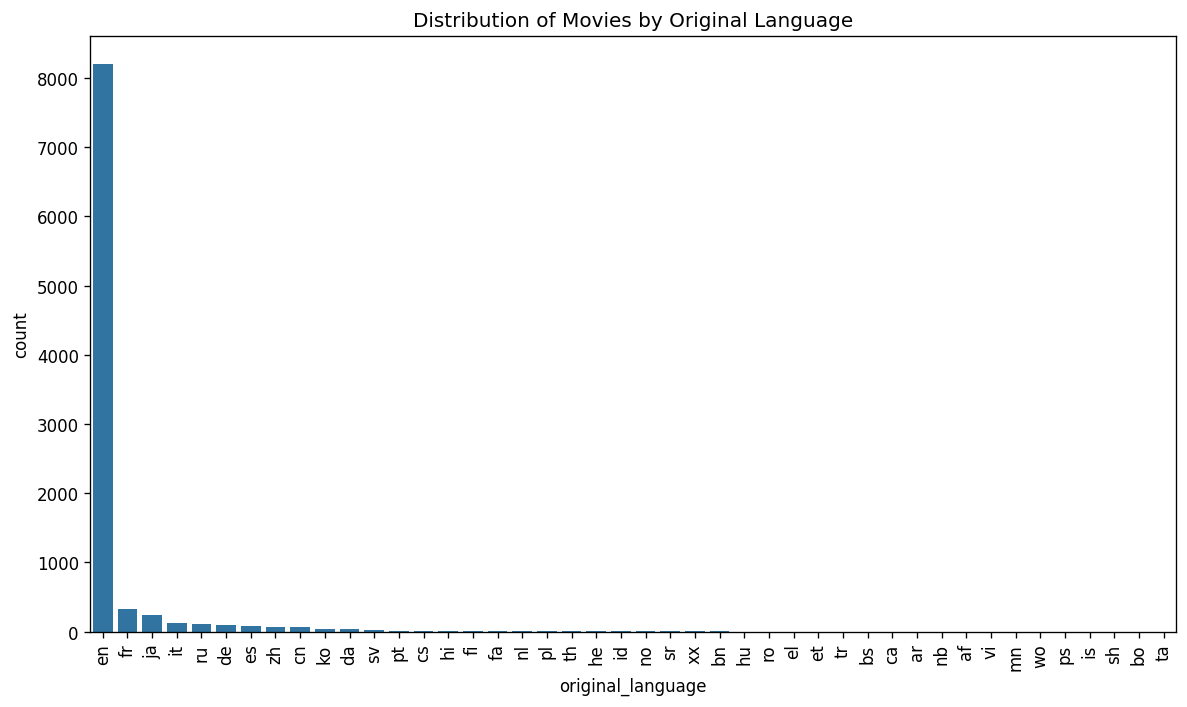


**Interpretation: Distribution of Movies by Original Language**

Movies in the catalog are overwhelmingly English-language; “en” accounts for the vast majority of titles. Other languages such as French, Japanese, Italian, Russian, German, and Spanish appear but with much smaller counts, and many languages are represented only by a handful of films. This suggests that, in practice, recommendations will mostly involve English-language content, and performance metrics will be driven primarily by this subset.

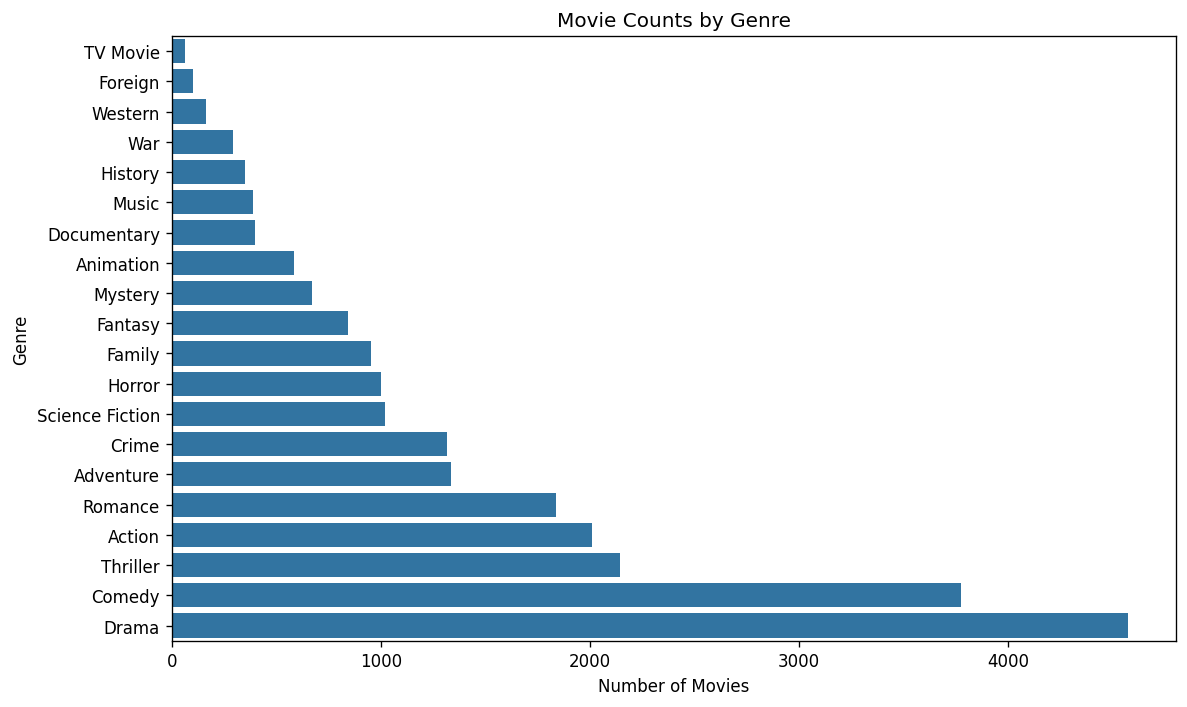


**Interpretation: Movie Counts by Genre**

Genre counts show that Drama and Comedy dominate the catalog, followed by Thriller, Action, and Romance. Mid-tier genres such as Adventure, Crime, Science Fiction, and Horror are also well represented, while categories like Documentary, Music, History, War, Western, Foreign, and TV Movie are relatively rare. This means the recommender has rich data to learn patterns for mainstream genres but much less signal for niche genres, which may affect recommendation quality for users with highly specialized tastes.

## 5. Model Training and Predictions

I train two collaborative filtering models using the Surprise library:

- **SVD (matrix factorization)** – a model-based approach that learns latent user and item factors.

- **KNNBaseline** – a memory-based method that predicts ratings from similar users/items with baseline adjustments.

I perform grid search over a small hyperparameter space for each model using RMSE on a validation set, then retrain the best configuration on the full training data and evaluate on a held-out test set.

In [8]:
# Data prep for the models - Surprise models dont accept pandas dataframes
surprise_data = build_surprise_data(ml_ratings_raw)
train_data, test_data = surprise_train_test_split(surprise_data, test_size=0.2, random_state=42)

# 1. SVD
# ---------------------------------------------------------------
best_param, best_score = tune_SVD(surprise_data, cv=3)
best_param_relevant = {"n_factors": best_param.get("n_factors"), "reg_all": best_param.get("reg_all"), "lr_all": best_param.get("lr_all")}
print("\n\t\t\t  For Matrix Factorization (SVD)\n"+"-"*80)
print(f"Best score: {best_score:.4f}")
print(f"Best params: {best_param_relevant}")
svd_estimator = SVD(**best_param)
svd_estimator.fit(train_data)
algo, rmse, preds = predict_for_test(svd_estimator, test_data)
print(f"Test RMSE: {rmse:.4f}")
svd_row = {"best_cv_rmse": best_score, "test_rmse": rmse, "n_factors": best_param.get("n_factors"), "reg_all": best_param.get("reg_all"), "lr_all": best_param.get("lr_all"),
           # placeholders for SVD-only params
           "k": None, "sim_name": None, "user_based": None}
svd_results_df = pd.DataFrame([svd_row], index=["SVD"])
svd_pred_df = predictions_to_dataframe(preds)
svd_pred_df.to_csv(outdir/"svd_predictions.csv", index=False)

# 2. KNN
# -----------------------------------------------------------------
best_param, best_score = tune_knn_baseline(surprise_data, cv=3)
best_param_relevant = {"k": best_param.get("k"), "sim_options": best_param.get("sim_options")}
print("\n\t\t\t\tFor KNNBaseline\n"+"-"*80)
print(f"Best score: {best_score:.4f}")
print(f"Best params: {best_param_relevant}")
knn_estimator = KNNBaseline(**best_param)
knn_estimator.fit(train_data)
algo, rmse, preds = predict_for_test(knn_estimator, test_data)
print(f"Test RMSE: {rmse:.4f}")
sim_opts = best_param.get("sim_options", {})
knn_row = {"best_cv_rmse": best_score, "test_rmse": rmse, "k": best_param.get("k"), "sim_name": sim_opts.get("name"), "user_based": sim_opts.get("user_based"),
        # placeholders for SVD-only params
        "n_factors": None, "reg_all": None, "lr_all": None}
knn_results_df = pd.DataFrame([knn_row], index=["KNNBaseline"])
knn_pred_df = predictions_to_dataframe(preds)
knn_pred_df.to_csv(outdir/"knn_predictions.csv", index=False)

# combining results for both models in a pandas DataFrame and saving it in results directory
results_df = pd.concat([svd_results_df, knn_results_df], axis=0)
results_df.to_csv(outdir/"model_results.csv")



			  For Matrix Factorization (SVD)
--------------------------------------------------------------------------------
Best score: 0.8593
Best params: {'n_factors': 250, 'reg_all': 0.1, 'lr_all': 0.025}
Test RMSE: 0.8582

				For KNNBaseline
--------------------------------------------------------------------------------
Best score: 0.8632
Best params: {'k': 50, 'sim_options': {'name': 'pearson_baseline', 'user_based': False}}
Test RMSE: 0.8597


**Analysis**

The two collaborative filtering models achieve very similar accuracy on the MovieLens test set. SVD (matrix factorization) attains a slightly lower cross-validated RMSE (approx. 0.86) and test RMSE (approx. 0.858) than KNNBaseline (cv RMSE approx. 0.864 and test RMSE approx. 0.86), indicating a marginal performance advantage for the latent-factor model.

The tuned SVD model uses a relatively high number of factors with moderate regularization (0.1) and learning rate (0.025), suggesting that capturing rich latent structure in user and item preferences is beneficial. The KNNBaseline model, configured with k = 50 neighbors and Pearson baseline similarity in an item-based setting, remains competitive but does not quite match SVD’s performance.

Overall, both models perform well, but SVD provides slightly better predictive accuracy, so it can be considered the primary model for rating prediction, while KNNBaseline is still valuable as an interpretable, memory-based baseline for qualitative comparison of recommendations.

## 6. Comparing Top-N SVD and KNN Recommendations

To better understand qualitative differences between the two models, I generate top-N recommendations for a few sample users and compare the movie lists side by side.

This helps reveal where the models agree, where they diverge, and which model tends to recommend more popular or more niche titles.

In [9]:
# Checking top-n recommendations of both models for some user
user_list = [50,100,200]
print("\n\t  Comparison of top-N KNNBaseline and SVD predictions for few users\n" + "-" * 80)
for user in user_list:
    compare_model_recommendations(svd_model=svd_estimator, knn_model=knn_estimator, user_id=user, ratings_df=ml_ratings_raw, metadata_df=meta_merged, n=10)


	  Comparison of top-N KNNBaseline and SVD predictions for few users
--------------------------------------------------------------------------------

Comparison for user 50 (top-10)
- SVD only: Number - 10 | Titles - ['A Streetcar Named Desire', 'Paths of Glory', 'Double Indemnity', "Guess Who's Coming to Dinner", 'Slap Shot', 'Belle Époque', 'The Trial', 'Memories of Murder', 'Sophie Scholl: The Final Days', nan]
- KNN only: Number - 10 | Titles - ['Vanya on 42nd Street', 'Thirty Two Short Films About Glenn Gould', 'Alphaville', 'Rear Window', 'North by Northwest', 'The Third Man', 'Touch of Evil', 'Mrs. Miniver', 'An Affair of Love', 'O']
- Overlap: Number - 0 | Titles - []

Comparison for user 100 (top-10)
- SVD only: Number - 10 | Titles - ['Paths of Glory', 'The Last Detail', 'The Trial', "Adam's Rib", 'The End of Evangelion', 'Joint Security Area', 'Sophie Scholl: The Final Days', 'Enter the Void', 'Cosmos', nan]
- KNN only: Number - 10 | Titles - ['Destiny Turns on the Radio',

**Comparison of SVD vs. KNN Recommendations**

For the three sample users examined, the SVD and KNNBaseline models produced distinct, non-overlapping Top-N recommendation lists. This lack of overlap highlights fundamental differences in how the two algorithms interpret user preferences.

SVD, being a model-based latent factor approach, captures deeper patterns across the entire rating matrix, often recommending movies that align with inferred user–item affinities—even if the items are not highly similar on the surface. In contrast, KNNBaseline relies on explicit item–item similarity, favoring movies that are closely related to those the user has already rated.

Because the two models use different sources of information—one latent and global, the other local and similarity-driven—the divergence in recommendations is expected. The absence of shared titles across users suggests that each model is emphasizing different aspects of user taste, and together they provide complementary perspectives on what a user might enjoy.

This qualitative contrast is valuable: SVD may excel at uncovering hidden preferences, while KNNBaseline surfaces more intuitive, similarity-based suggestions.

## 7. External Validation - Comparison of Predictions with IMDB Ratings

Finally, I validate the predicted ratings against the IMDb average ratings, which serve as an independent external benchmark.
For each model, I compute the correlation between its predicted ratings (on the test set) and the IMDb averages for movies where such ratings are available.

In [10]:
# Validation of model predictions against external ratings (imdb)
print("\nExternal Validation - Comparison of KNNBaseline/SVD predictions and IMDB Ratings\n"+"-"*80)
svd_corr = imdb_validation(svd_pred_df, meta_merged, model_name="SVD")
knn_corr = imdb_validation(knn_pred_df, meta_merged, model_name="KNNBaseline")


External Validation - Comparison of KNNBaseline/SVD predictions and IMDB Ratings
--------------------------------------------------------------------------------
[SVD] - Correlation between predicted rating and IMDb average rating: 0.613
[KNNBaseline] - Correlation between predicted rating and IMDb average rating: 0.536


**External Validation Using IMDb Ratings**

To assess how well each model’s predicted ratings align with real-world audience reception, I compared the predictions on the MovieLens test set with the corresponding IMDb average ratings. This provides an external, independent benchmark outside the training data.

The SVD model achieves a correlation of approximately 0.613, indicating a moderately strong positive relationship between its predicted ratings and IMDb’s aggregated user scores. In contrast, the KNNBaseline model produces a lower correlation of around 0.536, suggesting weaker alignment with external ratings.

This result reinforces the earlier RMSE findings: SVD not only predicts MovieLens ratings more accurately but also generalizes better to external data. Its latent factor structure captures broader patterns in user preferences that appear to transfer well across platforms. Meanwhile, KNNBaseline remains competitive but shows more variability and weaker correspondence with IMDb evaluations.

Overall, the external validation highlights SVD as the more reliable and robust recommender, providing predictions that better reflect real-world audience sentiment.

## 8. Conclusions

This project developed and evaluated a movie recommender system using two collaborative filtering approaches—SVD (matrix factorization) and KNNBaseline (memory-based item similarity)—on the MovieLens dataset enriched with Kaggle movie metadata and validated against IMDb ratings.

Across all evaluation stages, the SVD model consistently outperformed KNNBaseline. SVD achieved slightly lower RMSE on the MovieLens test set and demonstrated a stronger external correlation with IMDb ratings (approx. 0.61) compared to KNNBaseline (approx. 0.54). These results indicate that SVD’s latent factor representation captures deeper, more transferable patterns in user preferences that align well with real-world audience sentiment.

The qualitative comparison of recommendations further highlighted the differences between the models. SVD produced more diverse, latent-driven suggestions, while KNNBaseline emphasized surface-level item similarity. The complete lack of overlap in the Top-N recommendations for sample users underscores how the two approaches prioritize different aspects of user taste. In practice, this suggests that combining the strengths of both methods—or creating a hybrid system—could provide richer and more balanced recommendations.

The exploratory data analysis also revealed important characteristics of the dataset: a highly sparse user–item interaction matrix, a strong dominance of English-language content, and significant variation in genre and release-year coverage. These patterns help contextualize model behavior and potential limitations, especially for users with niche or less-represented preferences.

Overall, the project demonstrates that model-based collaborative filtering—particularly matrix factorization—remains a powerful and effective approach for personalized recommendation tasks.